In [1]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
print("Success!")

Success!


In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

# Load the saved sample
df_sample = pd.read_csv("reddit_sample.csv")

# Apply sentiment analysis
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    return score['compound']

def get_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

print("Running sentiment analysis... this may take a few minutes")
df_sample['sentiment_score'] = df_sample['body'].apply(get_sentiment)
df_sample['sentiment_label'] = df_sample['sentiment_score'].apply(get_label)

print("Done!")
print(df_sample['sentiment_label'].value_counts())

df_sample.to_csv("reddit_sample_sentiment.csv", index=False)
print("\nSaved!")

Running sentiment analysis... this may take a few minutes
Done!
sentiment_label
positive    140248
negative     53762
neutral       5990
Name: count, dtype: int64

Saved!


In [6]:
import sys
!{sys.executable} -m pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 9.9 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=8f61a4335e590e0ed20b5e041af9fb27ddab292d147e31fae167857945826374
  Stored in directory: c:\users\jerry\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [7]:
import yfinance as yf
import pandas as pd

# Top stocks commonly discussed in finance subreddits
tickers = ['AAPL', 'TSLA', 'AMZN', 'MSFT', 'GOOG', 'SPY', 'GME', 'NFLX']

# Download stock data 2018-2020 to match our Reddit sample
df_stocks = yf.download(tickers, start="2018-01-01", end="2020-12-31")

# Keep only closing prices
df_close = df_stocks['Close']
df_close.reset_index(inplace=True)

print("Shape:", df_close.shape)
print(df_close.head())

df_close.to_csv("stock_data.csv", index=False)
print("\nSaved!")

[*********************100%***********************]  8 of 8 completed

Shape: (755, 9)
Ticker       Date       AAPL       AMZN       GME       GOOG       MSFT  \
0      2018-01-02  40.304176  59.450500  3.988465  52.816380  78.870346   
1      2018-01-03  40.297142  60.209999  3.975359  53.683262  79.237419   
2      2018-01-04  40.484348  60.479500  4.001569  53.877666  79.934792   
3      2018-01-05  40.945267  61.457001  4.080204  54.662720  80.925865   
4      2018-01-08  40.793182  62.343498  4.200337  54.896305  81.008461   

Ticker       NFLX         SPY       TSLA  
0       20.107000  236.562119  21.368668  
1       20.504999  238.058472  21.150000  
2       20.563000  239.061768  20.974667  
3       20.999001  240.654922  21.105333  
4       21.205000  241.094986  22.427334  

Saved!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both datasets
df_reddit = pd.read_csv("reddit_sample_sentiment.csv")
df_stocks = pd.read_csv("stock_data.csv")

# Fix date columns
df_reddit['created_date'] = pd.to_datetime(df_reddit['created_date'])
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

print("Reddit shape:", df_reddit.shape)
print("Stocks shape:", df_stocks.shape)
print("\nReddit dtypes:\n", df_reddit.dtypes)
print("\nStocks dtypes:\n", df_stocks.dtypes)

Reddit shape: (200000, 15)
Stocks shape: (755, 9)

Reddit dtypes:
 created_date              datetime64[ns]
subreddit                         object
subreddit_id                      object
author                            object
body                              object
year                               int64
fog                              float64
num_letters                        int64
num_words                          int64
num_sentences                      int64
num_polysyllabic_words             int64
avg_words_per_sentence           float64
avg_syllables_per_word           float64
sentiment_score                  float64
sentiment_label                   object
dtype: object

Stocks dtypes:
 Date    datetime64[ns]
AAPL           float64
AMZN           float64
GME            float64
GOOG           float64
MSFT           float64
NFLX           float64
SPY            float64
TSLA           float64
dtype: object


<Figure size 1200x600 with 0 Axes>

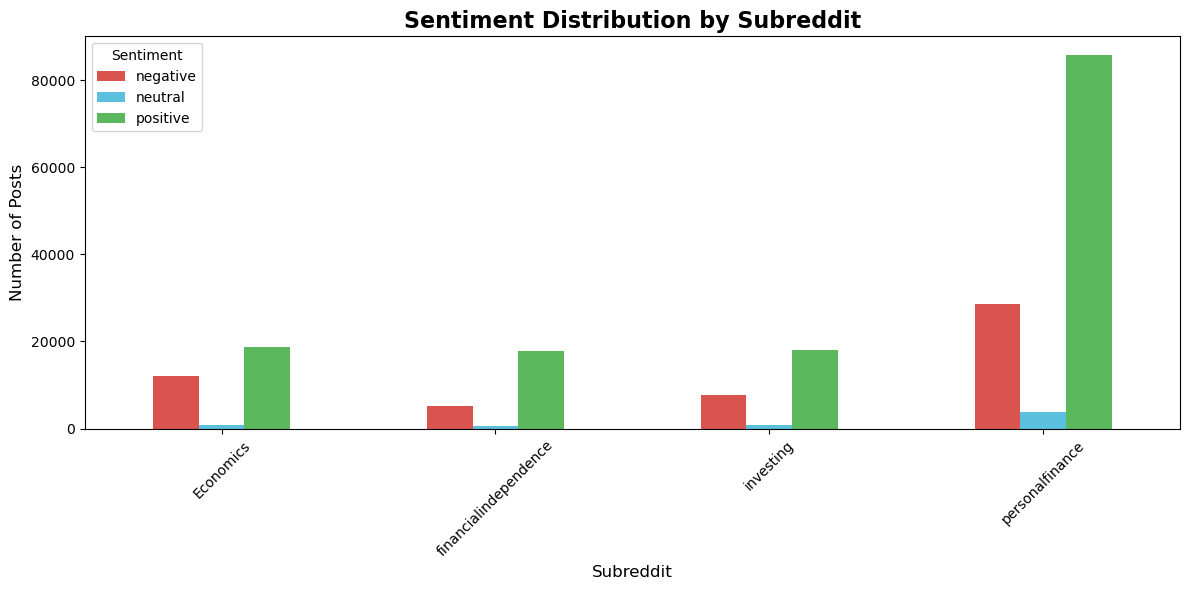

Visual 1 saved!


<Figure size 1400x600 with 0 Axes>

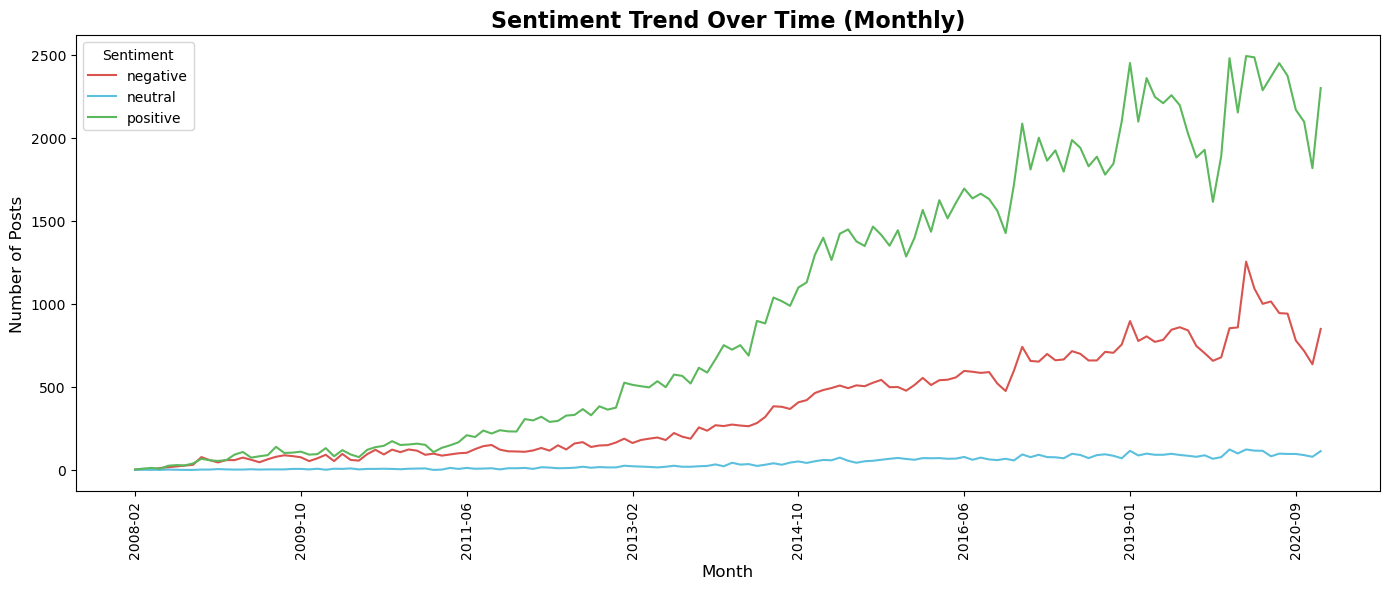

Visual 2 saved!


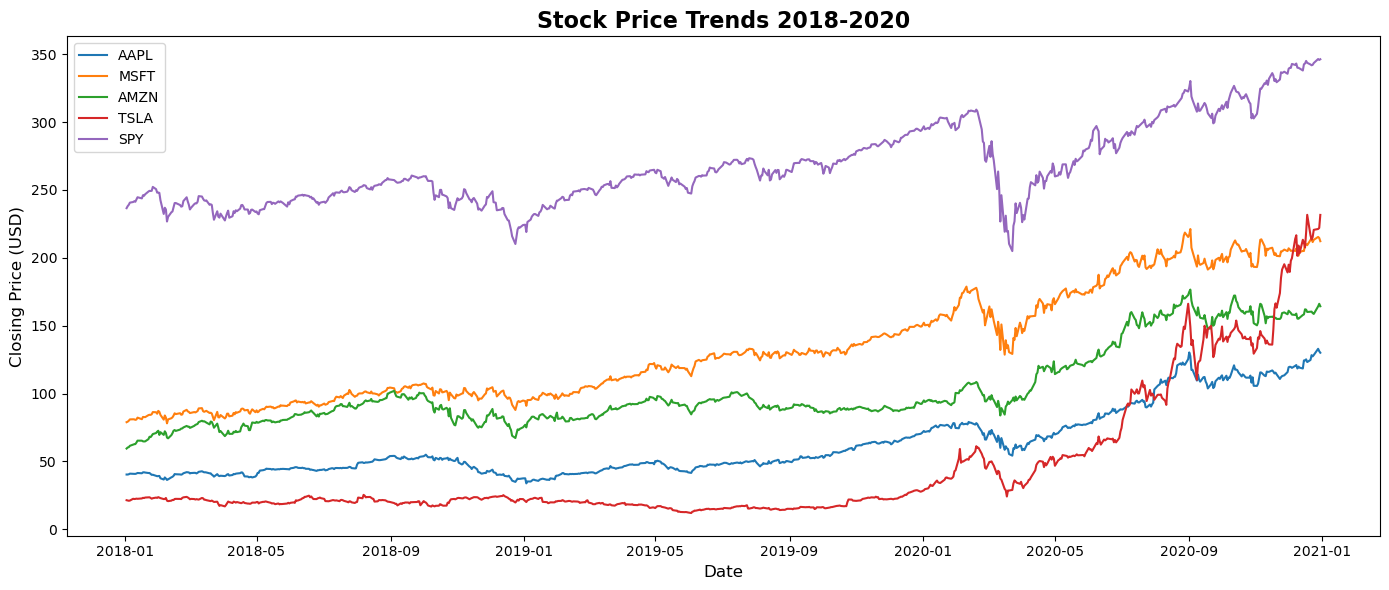

Visual 3 saved!


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_reddit = pd.read_csv("reddit_sample_sentiment.csv")
df_stocks = pd.read_csv("stock_data.csv")
df_reddit['created_date'] = pd.to_datetime(df_reddit['created_date'])
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

# ── Visual 1: Sentiment Distribution by Subreddit ──────────────────────────
plt.figure(figsize=(12, 6))
sentiment_counts = df_reddit.groupby(['subreddit', 'sentiment_label']).size().unstack()
sentiment_counts.plot(kind='bar', color=['#d9534f','#5bc0de','#5cb85c'], figsize=(12,6))
plt.title('Sentiment Distribution by Subreddit', fontsize=16, fontweight='bold')
plt.xlabel('Subreddit', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('visual1_sentiment_by_subreddit.png', dpi=150)
plt.show()
print("Visual 1 saved!")

# ── Visual 2: Sentiment Trend Over Time ────────────────────────────────────
plt.figure(figsize=(14, 6))
df_reddit['year_month'] = df_reddit['created_date'].dt.to_period('M')
monthly = df_reddit.groupby(['year_month', 'sentiment_label']).size().unstack().fillna(0)
monthly.index = monthly.index.astype(str)
monthly.plot(kind='line', color=['#d9534f','#5bc0de','#5cb85c'], figsize=(14,6))
plt.title('Sentiment Trend Over Time (Monthly)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('visual2_sentiment_over_time.png', dpi=150)
plt.show()
print("Visual 2 saved!")

# ── Visual 3: Stock Price Trends 2018-2020 ─────────────────────────────────
plt.figure(figsize=(14, 6))
for col in ['AAPL', 'MSFT', 'AMZN', 'TSLA', 'SPY']:
    plt.plot(df_stocks['Date'], df_stocks[col], label=col)
plt.title('Stock Price Trends 2018-2020', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('visual3_stock_trends.png', dpi=150)
plt.show()
print("Visual 3 saved!")

In [10]:
# Extra stats for report
print("=== Sentiment by Subreddit ===")
print(df_reddit.groupby(['subreddit','sentiment_label']).size().unstack())

print("\n=== Average Sentiment Score by Subreddit ===")
print(df_reddit.groupby('subreddit')['sentiment_score'].mean())

print("\n=== Average Sentiment Score by Year ===")
print(df_reddit.groupby('year')['sentiment_score'].mean())

print("\n=== Stock % Change 2018-2020 ===")
for col in ['AAPL','TSLA','AMZN','MSFT','GOOG','SPY','GME','NFLX']:
    change = ((df_stocks[col].iloc[-1] - df_stocks[col].iloc[0]) / df_stocks[col].iloc[0]) * 100
    print(f"{col}: {change:.1f}%")

=== Sentiment by Subreddit ===
sentiment_label        negative  neutral  positive
subreddit                                         
Economics                 12148      814     18623
financialindependence      5165      671     17886
investing                  7768      746     17985
personalfinance           28681     3759     85754

=== Average Sentiment Score by Subreddit ===
subreddit
Economics                0.162216
financialindependence    0.431129
investing                0.309117
personalfinance          0.383736
Name: sentiment_score, dtype: float64

=== Average Sentiment Score by Year ===
year
2008    0.049171
2009    0.128653
2010    0.121461
2011    0.199273
2012    0.310056
2013    0.354737
2014    0.365238
2015    0.362542
2016    0.370881
2017    0.363577
2018    0.361595
2019    0.350928
2020    0.332844
Name: sentiment_score, dtype: float64

=== Stock % Change 2018-2020 ===
AAPL: 222.7%
TSLA: 983.8%
AMZN: 176.4%
MSFT: 169.1%
GOOG: 63.3%
SPY: 46.4%
GME: 20.7%
NFLX: 16